[![Binder](https://mybinder.org/badge_logo.svg)](https://notebooks.gesis.org/binder/v2/gh/joshmaglione/CS102-Jupyter/main?labpath=.%2F08_Matplotlib.ipynb) 

<a href="https://colab.research.google.com/github/joshmaglione/CS102-Jupyter/blob/main/08_Matplotlib.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> 

[View on GitHub](https://github.com/joshmaglione/CS102-Jupyter/blob/main/08_Matplotlib.ipynb)

# 08 : Plotting Data in Python

## Learning outcomes
By the end of this notebook, you should be able to:
- create clear plots with Matplotlib using the Figure/Axes pattern
- label and style plots (titles, axis labels, legends) so they communicate effectively
- plot common data types (including time series) from `pandas`

We will continue discussing pandas, but now we will be primarily focused on visualization. 

### Time data.

Dealing with time data is generally tricky. There are 
- timezones
- daylight savings
- bizarre formatting
- inconsistent numbers (months have 28, 29, 30, 31 days)

Moreover, time data is often not just a number (e.g. like an integer).

A common Python package for dealing with time data is `datetime`. 

`pandas` has tools to deal with time data.

Often one needs to give pandas a hint at how time data is formatted, and then pandas can reformat however is required. 

There are four basic styles (taken directly from pandas doc referenced below):
1. Date times: A specific date and time with timezone support. Similar to `datetime.datetime` from the standard library.
2. Time deltas: An absolute time duration. Similar to `datetime.timedelta` from the standard library.
3. Time spans: A span of time defined by a point in time and its associated frequency.
4. Date offsets: A relative time duration that respects calendar arithmetic. Similar to `dateutil.relativedelta.relativedelta` from the `dateutil` package.

If you want to be overwhelmed by all that pandas can do with time data:

[check this out](https://pandas.pydata.org/docs/user_guide/timeseries.html).

In [1]:
import pandas as pd

We will look at the publicly available [HPSC's Covid-19 county data](https://data.gov.ie/dataset/covid-19-hpsc-county-statistics-historic-data1).

In [2]:
df = pd.read_csv(
	"data/COVID-19_HPSC_County_Statistics_Historic_Data.csv", 
	index_col='TimeStamp', parse_dates=True
)
df.head()

,OBJECTID,ORIGID,CountyName,PopulationCensus16,IGEasting,IGNorthing,Lat,Long,UGI,ConfirmedCovidCases,PopulationProportionCovidCases,ConfirmedCovidDeaths,ConfirmedCovidRecovered,SHAPE_Length,SHAPE_Area
TimeStamp,,,,,,,,,,,,,,,
2020-02-27 00:00:00+00:00,1,1,Carlow,56932,278661,163444,52.7168,-6.8367,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,2.284159,0.118863
2020-02-27 00:00:00+00:00,2,2,Cavan,76176,246380,304501,53.9878,-7.2937,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,3.767411,0.264466
2020-02-27 00:00:00+00:00,3,3,Clare,118817,133493,182732,52.8917,-8.9889,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,7.575907,0.425059
2020-02-27 00:00:00+00:00,4,4,Cork,542868,156242,77860,51.9517,-8.6372,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,16.284223,0.972002
2020-02-27 00:00:00+00:00,5,5,Donegal,159192,202615,405691,54.8989,-7.9600,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,15.626908,0.678171


Let's split off two counties.

[Recall that `query` defaults to making a copy while slicing defaults to a view.]

In [3]:
df_gal = df.query("CountyName == 'Galway'")
df_gal.head()

,OBJECTID,ORIGID,CountyName,PopulationCensus16,IGEasting,IGNorthing,Lat,Long,UGI,ConfirmedCovidCases,PopulationProportionCovidCases,ConfirmedCovidDeaths,ConfirmedCovidRecovered,SHAPE_Length,SHAPE_Area
TimeStamp,,,,,,,,,,,,,,,
2020-02-27 00:00:00+00:00,7,7,Galway,258058,151045,235818,53.3705,-8.7362,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,14.972448,0.822419
2020-03-01 00:00:00+00:00,33,7,Galway,258058,151045,235818,53.3705,-8.7362,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,14.972448,0.822419
2020-03-02 00:00:00+00:00,59,7,Galway,258058,151045,235818,53.3705,-8.7362,http://data.geohive.ie/resource/county/2ae1962...,0,0.0,NaN,NaN,14.972448,0.822419
2020-03-03 00:00:00+00:00,85,7,Galway,258058,151045,235818,53.3705,-8.7362,http://data.geohive.ie/resource/county/2ae1962...,0,0.0,NaN,NaN,14.972448,0.822419
2020-03-04 00:00:00+00:00,111,7,Galway,258058,151045,235818,53.3705,-8.7362,http://data.geohive.ie/resource/county/2ae1962...,0,0.0,NaN,NaN,14.972448,0.822419


In [4]:
df_gal["ConfirmedCovidCases"]

TimeStamp
2020-02-27 00:00:00+00:00        0
2020-03-01 00:00:00+00:00        0
2020-03-02 00:00:00+00:00        0
2020-03-03 00:00:00+00:00        0
2020-03-04 00:00:00+00:00        0
                             ...  
2023-11-09 00:00:00+00:00    93033
2023-11-10 00:00:00+00:00    93041
2023-11-11 00:00:00+00:00    93041
2023-11-12 00:00:00+00:00    93041
2023-11-13 00:00:00+00:00    93061
Name: ConfirmedCovidCases, Length: 1354, dtype: int64

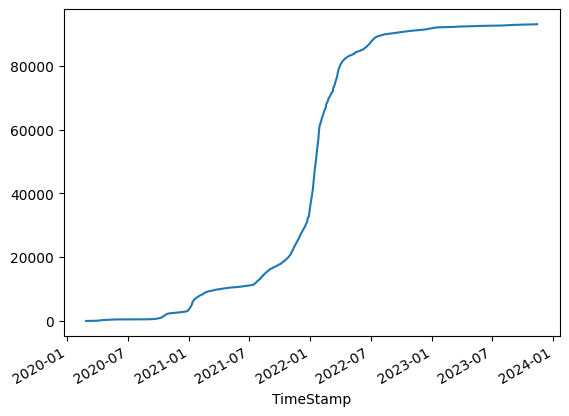

In [5]:
_ = df_gal["ConfirmedCovidCases"].plot()

Note that `pandas` already knows how to interpret the time data.

We can plot two counties manually

In [6]:
df_don = df.query("CountyName == 'Donegal'")
df_don.head()

,OBJECTID,ORIGID,CountyName,PopulationCensus16,IGEasting,IGNorthing,Lat,Long,UGI,ConfirmedCovidCases,PopulationProportionCovidCases,ConfirmedCovidDeaths,ConfirmedCovidRecovered,SHAPE_Length,SHAPE_Area
TimeStamp,,,,,,,,,,,,,,,
2020-02-27 00:00:00+00:00,5,5,Donegal,159192,202615,405691,54.8989,-7.96,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,15.626908,0.678171
2020-03-01 00:00:00+00:00,31,5,Donegal,159192,202615,405691,54.8989,-7.96,http://data.geohive.ie/resource/county/2ae1962...,0,NaN,NaN,NaN,15.626908,0.678171
2020-03-02 00:00:00+00:00,57,5,Donegal,159192,202615,405691,54.8989,-7.96,http://data.geohive.ie/resource/county/2ae1962...,0,0.0,NaN,NaN,15.626908,0.678171
2020-03-03 00:00:00+00:00,83,5,Donegal,159192,202615,405691,54.8989,-7.96,http://data.geohive.ie/resource/county/2ae1962...,0,0.0,NaN,NaN,15.626908,0.678171
2020-03-04 00:00:00+00:00,109,5,Donegal,159192,202615,405691,54.8989,-7.96,http://data.geohive.ie/resource/county/2ae1962...,0,0.0,NaN,NaN,15.626908,0.678171


In [7]:
gal_v_don = pd.DataFrame({
	"Galway": df_gal["ConfirmedCovidCases"], 
	"Donegal": df_don["ConfirmedCovidCases"]
})
gal_v_don.head()

,Galway,Donegal
TimeStamp,,
2020-02-27 00:00:00+00:00,0,0
2020-03-01 00:00:00+00:00,0,0
2020-03-02 00:00:00+00:00,0,0
2020-03-03 00:00:00+00:00,0,0
2020-03-04 00:00:00+00:00,0,0


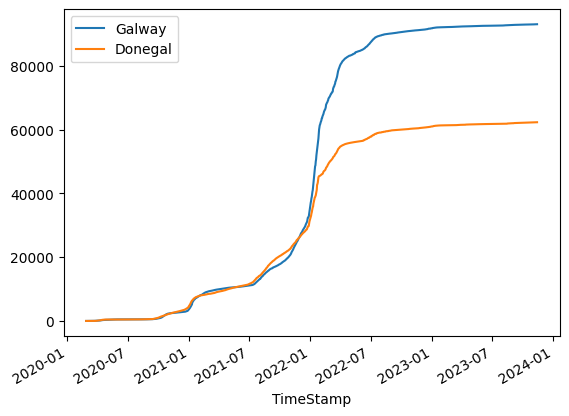

In [8]:
_ = gal_v_don.plot()

We can view specific years by accessing the `dt` attribute from the datetime data.

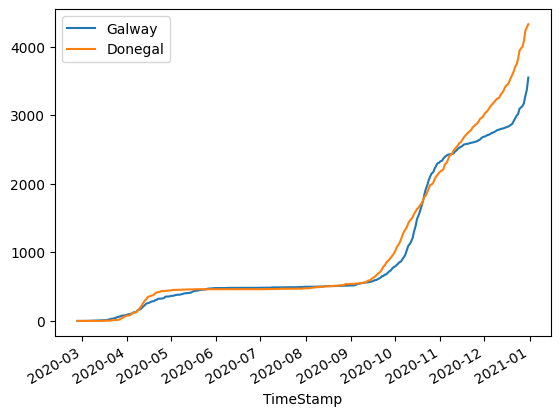

In [9]:
_ = gal_v_don.query("TimeStamp.dt.year == 2020").plot()

Cumulative data is nice, but the daily values are where the real drama is found!

We can use `diff` to take consecutive differences of our DataFrame. 

Since each row corresponds to a day, this will give us what we want.

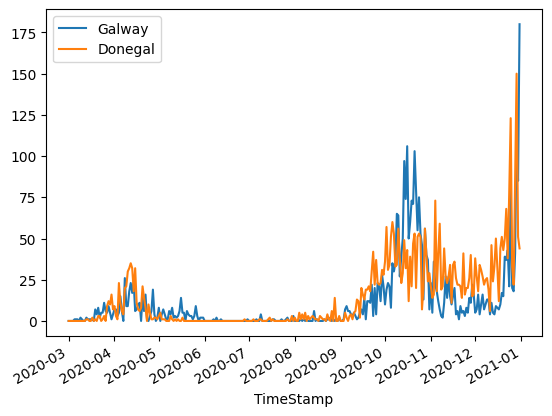

In [10]:
_ = (gal_v_don
  .query("TimeStamp.dt.year == 2020")
  .diff()
  .plot()
)

## Visualization with `Matplotlib`

In the background, [`Matplotlib`](https://matplotlib.org/) is running with `pandas` to make these nice plots. 

There are lots of [examples](https://matplotlib.org/stable/gallery/index.html) on the Matplotlib's webpage.

### Plotting curves

We'll do the simplest plots: plotting curves of the form $y=f(x)$. 

In [11]:
import numpy as np
import matplotlib.pyplot as plt

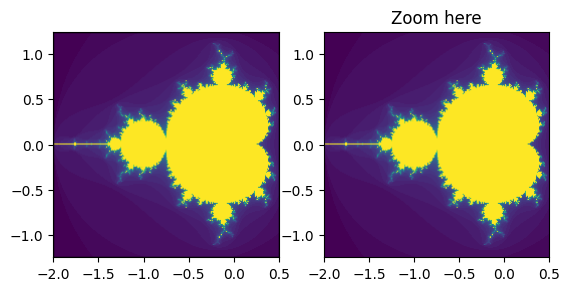

In [12]:
import functools

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Rectangle


# A class that will regenerate a fractal set as we zoom in, so that you
# can actually see the increasing detail.  A box in the left panel will show
# the area to which we are zoomed.
class MandelbrotDisplay:
    def __init__(self, h=500, w=500, niter=50, radius=2., power=2):
        self.height = h
        self.width = w
        self.niter = niter
        self.radius = radius
        self.power = power

    def compute_image(self, xlim, ylim):
        self.x = np.linspace(*xlim, self.width)
        self.y = np.linspace(*ylim, self.height).reshape(-1, 1)
        c = self.x + 1.0j * self.y
        threshold_time = np.zeros((self.height, self.width))
        z = np.zeros(threshold_time.shape, dtype=complex)
        mask = np.ones(threshold_time.shape, dtype=bool)
        for i in range(self.niter):
            z[mask] = z[mask]**self.power + c[mask]
            mask = (np.abs(z) < self.radius)
            threshold_time += mask
        return threshold_time

    def ax_update(self, ax):
        ax.set_autoscale_on(False)  # Otherwise, infinite loop
        # Get the number of points from the number of pixels in the window
        self.width, self.height = ax.patch.get_window_extent().size.round().astype(int)
        # Update the image object with our new data and extent
        ax.images[-1].set(data=self.compute_image(ax.get_xlim(), ax.get_ylim()),
                          extent=(*ax.get_xlim(), *ax.get_ylim()))
        ax.figure.canvas.draw_idle()


md = MandelbrotDisplay()

fig1, (ax_full, ax_zoom) = plt.subplots(1, 2)
ax_zoom.imshow([[0]], origin="lower")  # Empty initial image.
ax_zoom.set_title("Zoom here")

rect = Rectangle(
    [0, 0], 0, 0, facecolor="none", edgecolor="black", linewidth=1.0)
ax_full.add_patch(rect)


def update_rect(rect, ax):  # Let the rectangle track the bounds of the zoom axes.
    xlo, xhi = ax.get_xlim()
    ylo, yhi = ax.get_ylim()
    rect.set_bounds((xlo, ylo, xhi - xlo, yhi - ylo))
    ax.figure.canvas.draw_idle()


# Connect for changing the view limits.
ax_zoom.callbacks.connect("xlim_changed", functools.partial(update_rect, rect))
ax_zoom.callbacks.connect("ylim_changed", functools.partial(update_rect, rect))

ax_zoom.callbacks.connect("xlim_changed", md.ax_update)
ax_zoom.callbacks.connect("ylim_changed", md.ax_update)

# Initialize: trigger image computation by setting view limits; set colormap limits;
# copy image to full view.
ax_zoom.set(xlim=(-2, .5), ylim=(-1.25, 1.25))
im = ax_zoom.images[0]
ax_zoom.images[0].set(clim=(im.get_array().min(), im.get_array().max()))
ax_full.imshow(im.get_array(), extent=im.get_extent(), origin="lower")

plt.show()

Let's start with $f(x) = \sin(x)$ for $0\leqslant x \leqslant 4\pi$.

In [17]:
xs = np.linspace(0, 4*np.pi, 1000)
ys = np.sin(xs)

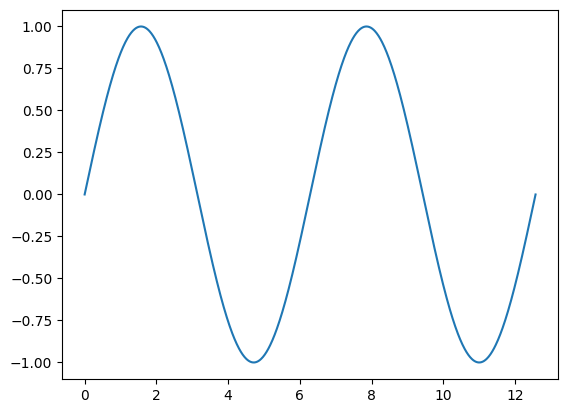

In [18]:
_ = plt.plot(xs, ys)

We can edit all sorts of data. Here's an example that we won't carefully go through.

It is fairly self-explanitory what each line is doing.

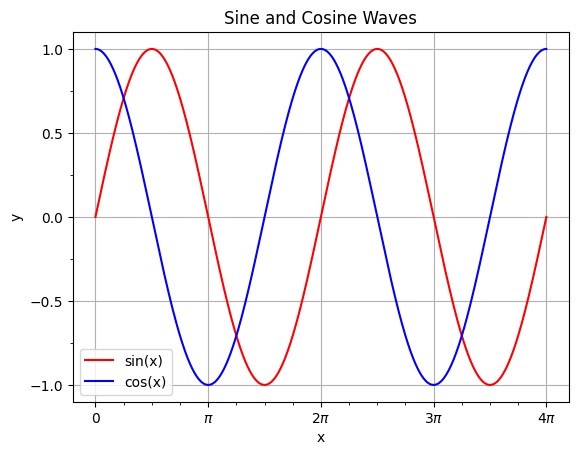

In [19]:
zs = np.cos(xs)			# Add a cosine wave

# Another common way to plot is to use the object-oriented interface
fig, ax = plt.subplots()
ax.grid(True)
ax.set_title("Sine and Cosine Waves")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.plot(xs, ys, c='r', label="sin(x)")
ax.plot(xs, zs, c='b', label="cos(x)")
ax.legend()
plt.xticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi], ['0', '$\\pi$', '$2\\pi$', '$3\\pi$', '$4\\pi$'])
ax.xaxis.set_minor_locator(plt.MultipleLocator(np.pi/4))
plt.yticks([-1, -0.5, 0, 0.5, 1])
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.25))
# plt.axis('equal')		# Make the x and y scales equal
_ = plt.show()

Color can be specified in many ways by using the `color` or just `c` keyword. If nothing is provided, Matplotlib will cycle through some default.

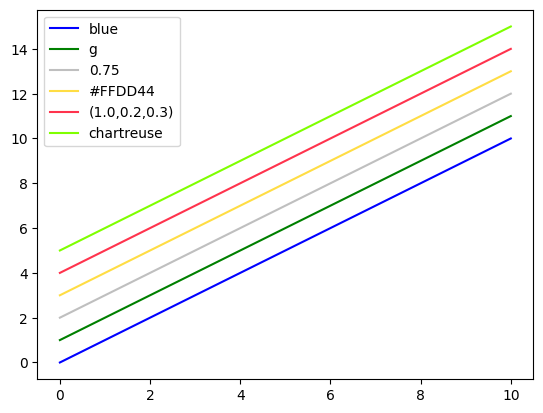

In [20]:
xs = np.linspace(0, 10, 100)

# specify color by name
plt.plot(xs, xs + 0, color='blue', label='blue') 

# short color code (rgbcmyk)
plt.plot(xs, xs + 1, color='g', label='g') 

# Grayscale between 0 and 1
plt.plot(xs, xs + 2, color='0.75', label='0.75') 

# Hex code (RRGGBB from 00 to FF)
plt.plot(xs, xs + 3, color='#FFDD44', label='#FFDD44') 

# RGB tuple, values 0 to 1
plt.plot(xs, xs + 4, color=(1.0,0.2,0.3), label='(1.0,0.2,0.3)') 

# all HTML color names supported
plt.plot(xs, xs + 5, color='chartreuse', label='chartreuse')

_ = plt.legend()

The line style can be adjusted using the `linestyle` keyword.

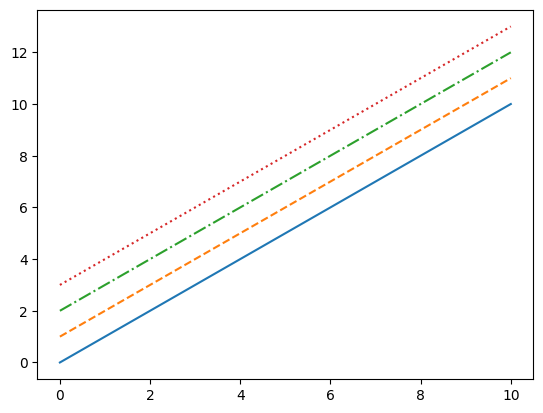

In [21]:
plt.plot(xs, xs + 0, linestyle='-')  	# solid
plt.plot(xs, xs + 1, linestyle='--') 	# dashed
plt.plot(xs, xs + 2, linestyle='-.') 	# dashdot
plt.plot(xs, xs + 3, linestyle=':')		# dotted
_ = plt.show()

Line style and color are such a common parameter to edit, that they can be combined without a keyword.

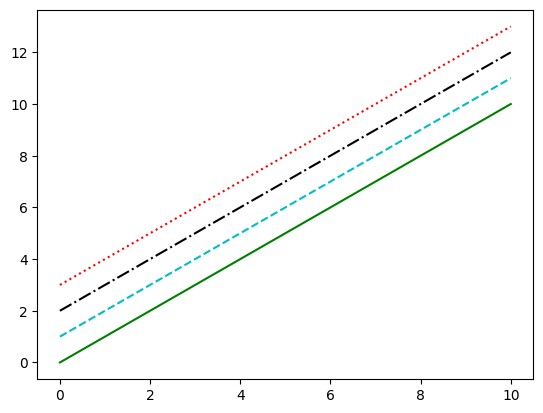

In [22]:
plt.plot(xs, xs + 0, '-g')  	# solid green
plt.plot(xs, xs + 1, '--c') 	# dashed cyan
plt.plot(xs, xs + 2, '-.k') 	# dashdot black
plt.plot(xs, xs + 3, ':r')  	# dotted red
_ = plt.show()

We could talk more about all of the specific aspects that can be changed in a plot. 

But I would rather show some cool pictures instead. 😅

## Scatter plots

Let's take our sine and cosine plots and add noise.

In [23]:
rng = np.random.default_rng(42)

xs = np.linspace(0, 4*np.pi, 100)
ys = np.sin(xs)
zs = np.cos(xs)

noise1 = rng.normal(0, 0.1, 100)
noise2 = rng.normal(0, 0.2, 100)

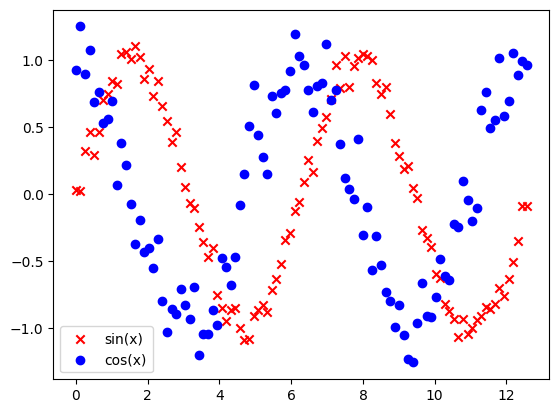

In [24]:
plt.scatter(xs, ys + noise1, c='r', label='sin(x)', marker='x')
plt.scatter(xs, zs + noise2, c='b', label='cos(x)', marker='o')
plt.legend()
_ = plt.show()

We can put our curves on this plot as well. 

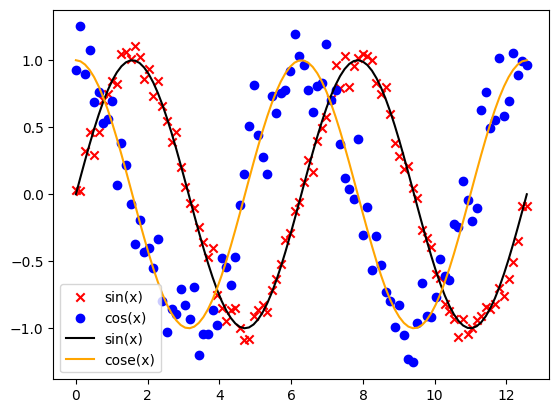

In [25]:
plt.scatter(xs, ys + noise1, c='r', label='sin(x)', marker='x')
plt.scatter(xs, zs + noise2, c='b', label='cos(x)', marker='o')
plt.plot(xs, ys, c='black', label="sin(x)")
plt.plot(xs, zs, c='orange', label="cose(x)")
plt.legend()
_ = plt.show()

By use of color and marker size, we can record two additional variables in our scatter plot. 

(Of course, this can be somewhat harder to discern, but it is helpful in som contexts.)

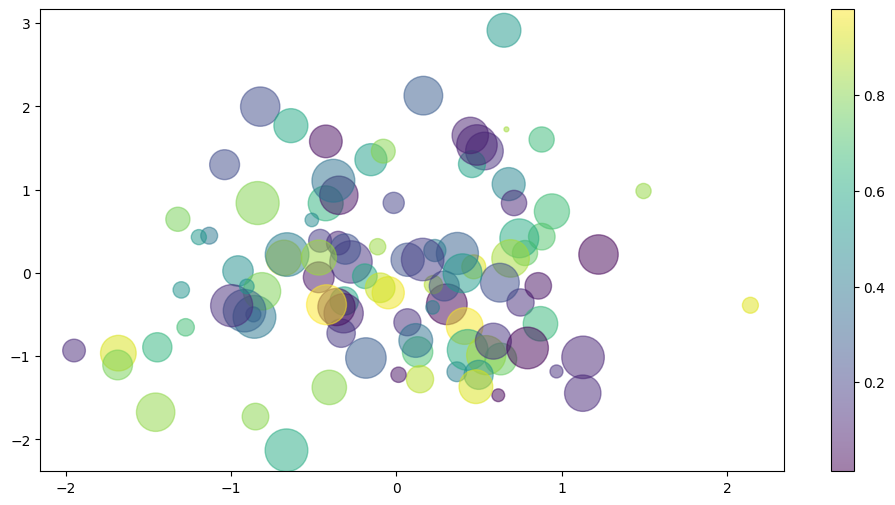

In [26]:
rng = np.random.default_rng(42)
x = rng.standard_normal(100)
y = rng.standard_normal(100)
colors = rng.random(100)
sizes = 1000 * rng.random(100)	# pixels

plt.figure(figsize=(12,6))	# Set the size of the figure
plt.scatter(x, y, c=colors, s=sizes, alpha=0.5, cmap='viridis')
plt.colorbar()
_ = plt.show()

The `color` (or `c`) argument is automatically mapped to a color scale -- shown by the `colorbar` command.

The size is also given in pixels.

#### The Iris data set

The [Iris data set](https://en.wikipedia.org/wiki/Iris_flower_data_set) is standard data set used for various reasons.

There are 50 samples of three species of Iris. Each sample has four measurements: length and width of the pedals and sepals.

In [27]:
from sklearn.datasets import load_iris
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

We will map the `target` array to color. Since there are only three speices, there will be three distinct colors.

We have three more dimensions we can display: $x$, $y$, and size. 

There are four measurements, so there are $4$ different sets of size $3$ we can consider. 

Of those $3$, there are essentially only $3$ different plots -- where interchanging $x$ and $y$ isn't really different.

In total, there are potentially $12$ distinct plots. Let's plot them all.

Here are some helper function to organize.

In [28]:
def triple(i, j, s=False):
	v = list(range(4))
	v.remove(3 - j)
	u = v[:i] + v[i+1:] + [v[i]]
	if s:
		return ''.join(map(str, u))
	return u

def scaled(arr, N=200):
	m = arr.max()
	return N/m * arr

Here's how we will organize. The string `'ijk'` represents the list `[i, j, k]`. 

The first two entries of the list are the $x$ and $y$ values, and the last entry is the size.

In [29]:
np.array([[triple(i, j, s=True) for j in range(4)] for i in range(3)])

array([['120', '130', '230', '231'],
       ['021', '031', '032', '132'],
       ['012', '013', '023', '123']], dtype='<U3')

Let's plot!

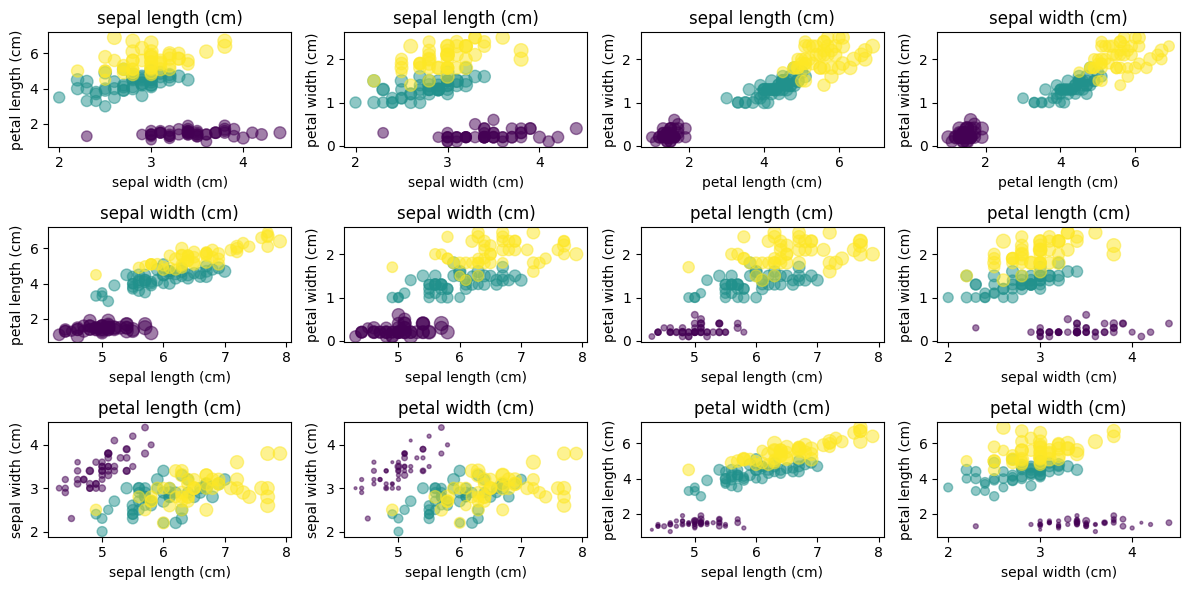

In [30]:
features = iris.data.T
fig, axs = plt.subplots(3, 4, figsize=(12, 6))
for i in range(3):
    for j in range(4):
        a, b, c = triple(i, j)
        axs[i, j].scatter(features[a], features[b], alpha=0.5,
            s=scaled(features[c], N=100), c=iris.target, cmap='viridis')
        axs[i, j].set_xlabel(iris.feature_names[a])
        axs[i, j].set_ylabel(iris.feature_names[b])
        axs[i, j].set_title(iris.feature_names[c])
plt.tight_layout()      # Make the labels fit
_ = plt.show()

Actually, there's some mathematics to do here to make this clear-cut.

I would do a principal component analysis (PCA).

Sciket-learn discusses that approach [in their tutorial](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html). 

[Foreshadowing]()

## Histograms

In a histogram, data are first grouped into *bins*, then the bins are plotted according to their size.

If the data is somewhat continuous, then this is a discretization of the data. 

Bar charts are often used for histograms.

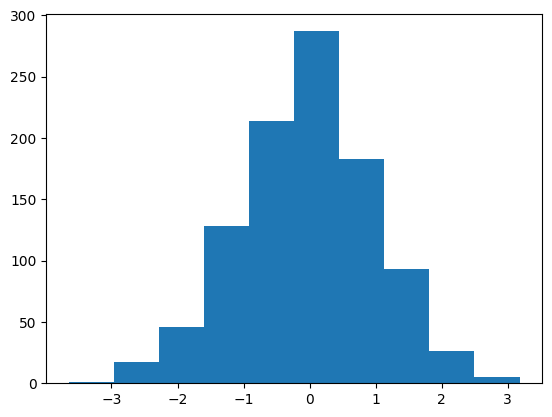

In [31]:
data1 = rng.normal(size=1000)
data2 = 4*rng.random(size=1000) - 2 
_ = plt.hist(data1, alpha=1)
# _ = plt.hist(data2, alpha=0.5)

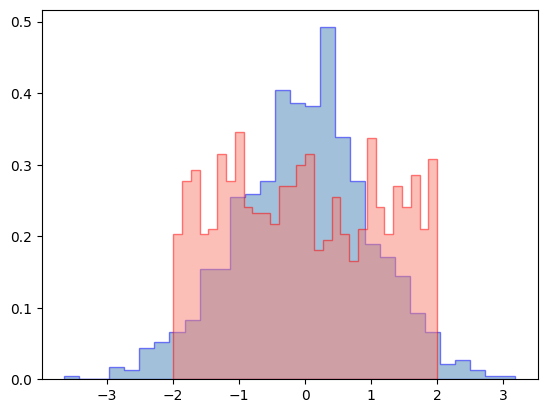

In [32]:
_ = plt.hist(data1, bins=30, density=True, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='blue')
_ = plt.hist(data2, bins=30, density=True, alpha=0.5, histtype='stepfilled', color='salmon', edgecolor='red')

'Steelblue' reminds me of ... 

![](imgs/Zoolander.jpg)

Anyways, if you need histogram data without the histogram, you can use NumPy.

In [33]:
counts, bin_edges = np.histogram(data1, bins=10)
print(counts)
print(bin_edges)

[  1  17  46 128 214 287 183  93  26   5]
[-3.64841283 -2.96568617 -2.28295952 -1.60023287 -0.91750622 -0.23477957
  0.44794708  1.13067373  1.81340038  2.49612703  3.17885368]


## Bonus

### Animations

One can animate in Jupyter notebooks via Matplotlib.

I learned about this on [Stack Overflow](https://stackoverflow.com/questions/35532498/animation-in-ipython-notebook/46878531)

Below I've copied directly from one of the answers. 

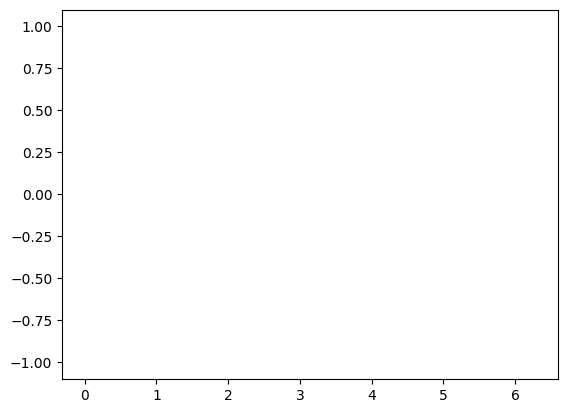

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["animation.html"] = "jshtml"
import matplotlib.animation
import numpy as np

t = np.linspace(0,2*np.pi)
x = np.sin(t)

fig, ax = plt.subplots()
l, = ax.plot([0,2*np.pi],[-1,1])

animate = lambda i: l.set_data(t[:i], x[:i])

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(t))
ani

### Grayscale image compression

In `Week01.ipynb`, we saw an example of image compression, but we consider an entirely different approach here.

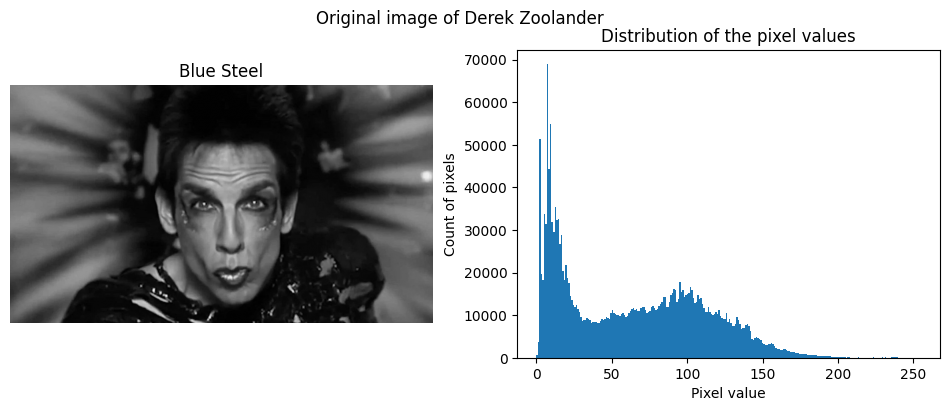

In [35]:
from PIL import Image

image_file = "imgs/Zoolander.jpg"

img = np.asarray(Image.open(image_file).convert("L"))
fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[0].axis("off")
ax[0].set_title("Blue Steel")
ax[1].hist(img.ravel(), bins=256)
ax[1].set_xlabel("Pixel value")
ax[1].set_ylabel("Count of pixels")
ax[1].set_title("Distribution of the pixel values")
_ = fig.suptitle("Original image of Derek Zoolander")

Now we compress the image.

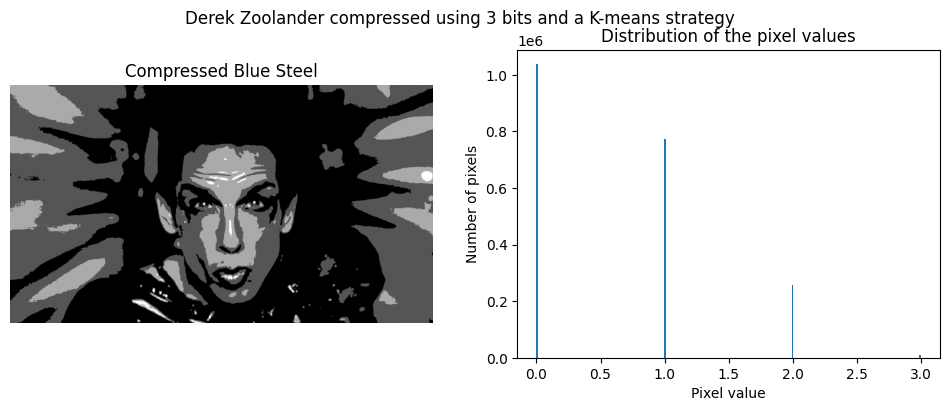

In [36]:
n_bins = 4

from sklearn.preprocessing import KBinsDiscretizer
encoder = KBinsDiscretizer(
    n_bins=n_bins,
    encode="ordinal",
    strategy="uniform",
    random_state=0,
    subsample=200_000,
)
compressed_img = encoder.fit_transform(img.reshape(-1, 1)).reshape(img.shape).astype(np.uint8)

fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
ax[0].imshow(compressed_img, cmap=plt.cm.gray)
ax[0].axis("off")
ax[0].set_title("Compressed Blue Steel")
ax[1].hist(compressed_img.ravel(), bins=256)
ax[1].set_xlabel("Pixel value")
ax[1].set_ylabel("Number of pixels")
ax[1].set_title("Distribution of the pixel values")
_ = fig.suptitle("Derek Zoolander compressed using 3 bits and a K-means strategy")

This example was taken partially from the [Scikit-learn tutorial](https://scikit-learn.org/stable/auto_examples/cluster/plot_face_compress.html).

## Exercises

1. Use suitable functions and ranges to plot a circle of radius $3$ around the centre $(1,1)$.
2. Plot the rational function $f(x) = \frac{x^2 + x - 2}{x^3 + 6}$ and its derivative $f'(x)$ so that all interesting points (zeros, extreme values, inflection points, singularities, ...) are contained in the plot.
3. Plot $f(x) = x^2 \sin(\pi/x)$ for $x$ in the range $[-0.3, 0.3]$.